made by : yumahazza

# Load Data

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import math
import cv2 as cv
from PIL import Image
import matplotlib.pyplot as plt

path1 = '/content/drive/MyDrive/GTI_GeometricTransformations/ImageRGB/image02.jpg'
path2 = '/content/drive/MyDrive/GTI_GeometricTransformations/ImageGray/imageg02.jpg'
img1_test = cv.imread(path1)
img2_test = cv.imread(path2)

print("Load Data Berhasil")

Load Data Berhasil


# View Data

## Gambar RGB

(427, 640)


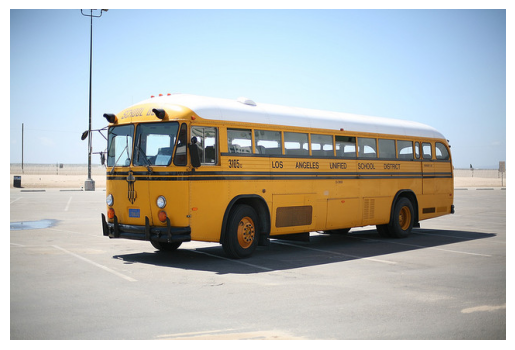

In [ ]:
img_rgb = cv.cvtColor(img1_test, cv.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis('off')
print(img_rgb.shape[:2])

## Gambar Gray

(600, 900)


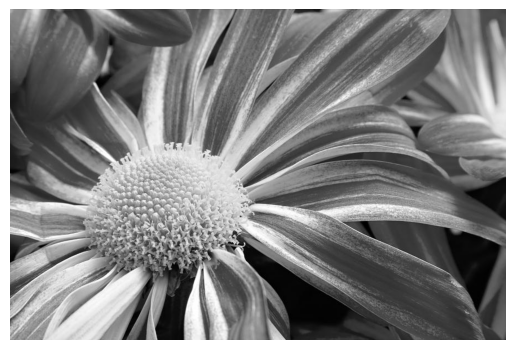

In [ ]:
img_gray = img2_test
plt.imshow(img_gray)
plt.axis('off')
print(img_gray.shape[:2])

# 1. Translation Function

A translation function is one of the function in geometric transformations that moves an image by adding values to the x-axis and y-axis.
<br>

The formula is defined as: <br>
${\displaylines{x’ = x + m}}$ <br>
${\displaylines{y’ = y + n}}$


## 1.1 Code

In [ ]:
def translasi(gambar, tx, ty):
    y, x = gambar.shape[:2]

    gambar_translasi = np.zeros((y, x, gambar.shape[2]), dtype = gambar.dtype)

    for i in range(y):
        for j in range(x):
            y_baru = i + ty
            x_baru = j + tx

            if y_baru >= 0 and y_baru < y and x_baru >= 0 and x_baru < x:
                gambar_translasi[y_baru, x_baru] = gambar[i, j]

    return gambar_translasi

## 1.2 Implementation in RGB Image

(427, 640)


(np.float64(-0.5), np.float64(639.5), np.float64(426.5), np.float64(-0.5))

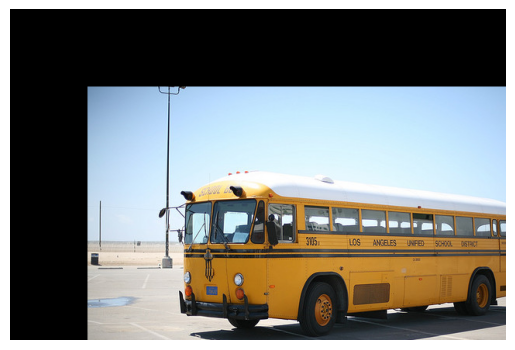

In [ ]:
img_rgb_translasi = translasi(img_rgb, 100, 100)
print(img_rgb_translasi.shape[:2])
plt.imshow(img_rgb_translasi)
plt.axis('off')

## 1.3 Implementation in Gray Image

(600, 900)


(np.float64(-0.5), np.float64(899.5), np.float64(599.5), np.float64(-0.5))

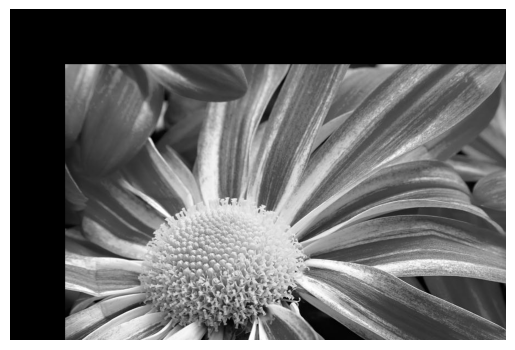

In [ ]:
img_gray_translasi = translasi(img_gray, 100, 100)
print(img_gray_translasi.shape[:2])
plt.imshow(img_gray_translasi)
plt.axis('off')

# 2. Rotation Function

A rotation function is one of the function in geometric transformations that rotates an image around a fixed point (usually the origin) by a given angle ${\displaystyle{\displaylines{\theta}}}$. The position of each point is changed based on the rotation angle.
<br>

The formula is defined as: <br>
${\displaylines{x’ = x.\cos(\theta) - y.\sin(\theta)}}$ <br>
${\displaylines{y’ = y.\sin(\theta) + y.\cos(\theta)}}$ <br>

## 2.1 Code

In [ ]:
def rotasi(gambar, sudut):
    y, x = gambar.shape[:2]

    cx = x / 2
    cy = y / 2

    theta = math.radians(sudut)
    cos_t = math.cos(theta)
    sin_t = math.sin(theta)

    pojok = [
        (-cx, -cy),
        ( x - cx, -cy),
        (-cx,  y - cy),
        ( x - cx,  y - cy)
    ]

    rotasi_pojok = []
    for i, j in pojok:
        x_r = i * cos_t - j * sin_t
        y_r = i * sin_t + j * cos_t
        rotasi_pojok.append((x_r, y_r))

    xs = [p[0] for p in rotasi_pojok]
    ys = [p[1] for p in rotasi_pojok]

    min_x, max_x = min(xs), max(xs)
    min_y, max_y = min(ys), max(ys)

    x_baru = int(np.round(max_x - min_x))
    y_baru = int(np.round(max_y - min_y))

    gambar_rotasi = np.zeros((y_baru, x_baru, gambar.shape[2]), dtype = gambar.dtype)

    cx_baru = x_baru / 2
    cy_baru = y_baru / 2

    for i in range(y_baru):
        for j in range(x_baru):
            x_rel = j - cx_baru
            y_rel = i - cy_baru

            x_lama = cos_t * x_rel + sin_t * y_rel + cx
            y_lama = -sin_t * x_rel + cos_t * y_rel + cy

            x_lama = int(x_lama)
            y_lama = int(y_lama)

            if 0 <= x_lama < x and 0 <= y_lama < y:
                gambar_rotasi[i, j] = gambar[y_lama, x_lama]

    return gambar_rotasi

## 2.2 Implementation in RGB Image

(640, 427)


(np.float64(-0.5), np.float64(426.5), np.float64(639.5), np.float64(-0.5))

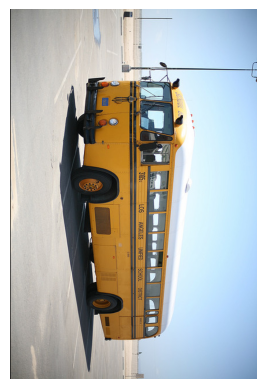

In [ ]:
img_rgb_rotasi = rotasi(img_rgb, 90)
print(img_rgb_rotasi.shape[:2])
plt.imshow(img_rgb_rotasi)
plt.axis('off')

## 2.3 Implementation in Gray Image

(600, 900)


(np.float64(-0.5), np.float64(899.5), np.float64(599.5), np.float64(-0.5))

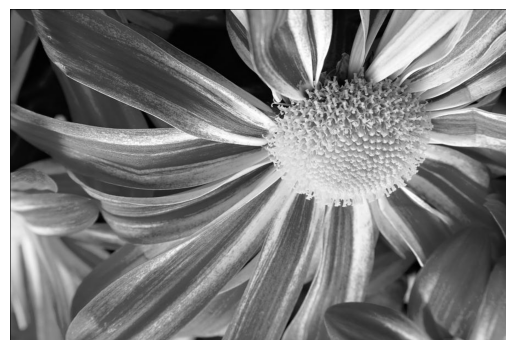

In [ ]:
img_gray_rotasi = rotasi(img_gray, 180)
print(img_gray_rotasi.shape[:2])
plt.imshow(img_gray_rotasi)
plt.axis('off')

# 3. Scaling Function

A scaling function also known as image scaling or image zooming, refers to the process of changing the size of an image (zooming out or zooming in).
<br><br>

Image scaling formula is defined as: <br>
${\displaylines{x’ = x.sx}}$ <br>
${\displaylines{y’ = y.sy}}$

## 3.1 Code

In [ ]:
def scaling(gambar, sx, sy):
    y, x = gambar.shape[:2]

    x_baru = int(x * sx)
    y_baru = int(y * sy)

    gambar_scaling = np.zeros((y_baru, x_baru, gambar.shape[2]), dtype = gambar.dtype)

    for i in range(y_baru):
        for j in range(x_baru):
            y_lama = int(i / sy)
            x_lama = int(j / sx)

            gambar_scaling[i, j] = gambar[y_lama, x_lama]

    return gambar_scaling

## 3.2 Implementation in RGB Image

(854, 1280)


(np.float64(-0.5), np.float64(1279.5), np.float64(853.5), np.float64(-0.5))

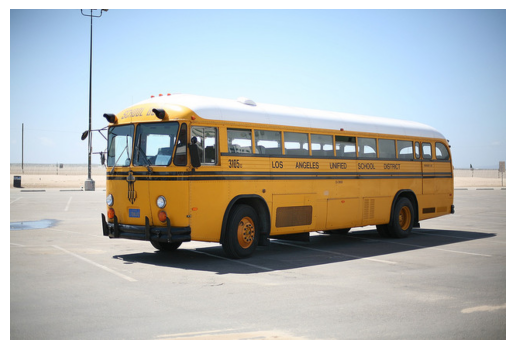

In [ ]:
img_rgb_scaling = scaling(img_rgb, 2, 2)
print(img_rgb_scaling.shape[:2])
plt.imshow(img_rgb_scaling)
plt.axis('off')

## 3.3 Implementation in Gray Image

(300, 450)


(np.float64(-0.5), np.float64(449.5), np.float64(299.5), np.float64(-0.5))

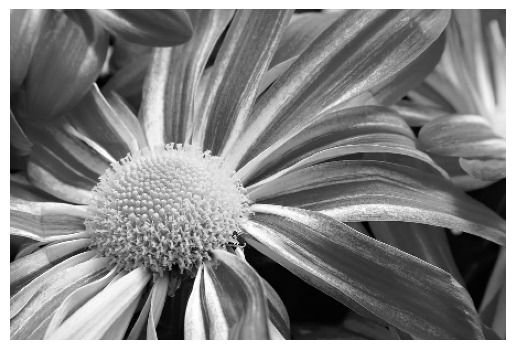

In [ ]:
img_gray_scaling = scaling(img_gray, 0.5, 0.5)
print(img_gray_scaling.shape[:2])
plt.imshow(img_gray_scaling)
plt.axis('off')

# 4. Fungsi Flip

A flipping function is a geometric operation equivalent to reflection
(image reflection). There are two types of flipping: horizontal and vertical. <br><br>

Horizontal Flipping Formula: <br>
${f’(x,y) = f(N-x,y)}$ <br><br>

Vertical Flipping Formula: <br>
${f’(x,y)=f(x,M-y)}$ <br>

## 4.1 Code

### 4.1.1 Flip Vertical

In [ ]:
def flip_vertical(gambar):
    y, x = gambar.shape[:2]

    gambar_flip = np.zeros((y, x, gambar.shape[2]), dtype = gambar.dtype)

    for i in range(y):
        for j in range(x):
            gambar_flip[y - 1 - i, j] = gambar[i, j]

    return gambar_flip

### 4.1.2 Flip Horizontal

In [ ]:
def flip_horizontal(gambar):
    y, x = gambar.shape[:2]

    gambar_flip = np.zeros((y, x, gambar.shape[2]), dtype = gambar.dtype)

    for i in range(y):
        for j in range(x):
            gambar_flip[i, x - 1 - j] = gambar[i, j]

    return gambar_flip

## 4.2 Implementation in RGB Image

### 4.2.1 Implementasi Flip Vertical

(427, 640)


(np.float64(-0.5), np.float64(639.5), np.float64(426.5), np.float64(-0.5))

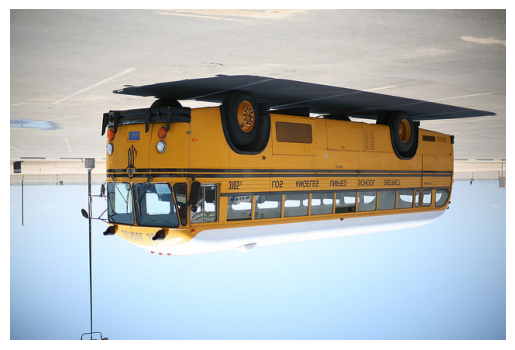

In [ ]:
img_rgb_fv = flip_vertical(img_rgb)
print(img_rgb_fv.shape[:2])
plt.imshow(img_rgb_fv)
plt.axis('off')

### 4.2.2 Implementasi Flip Horizontal

(427, 640)


(np.float64(-0.5), np.float64(639.5), np.float64(426.5), np.float64(-0.5))

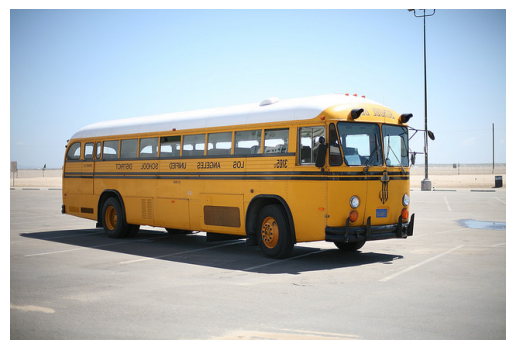

In [ ]:
img_rgb_fh = flip_horizontal(img_rgb)
print(img_rgb_fh.shape[:2])
plt.imshow(img_rgb_fh)
plt.axis('off')

## 4.3 Implementation in Gray Image

### 4.3.1 Implementasi Flip Vertical

(600, 900)


(np.float64(-0.5), np.float64(899.5), np.float64(599.5), np.float64(-0.5))

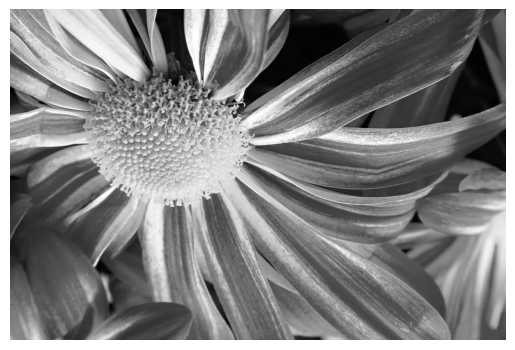

In [ ]:
img_gray_fv = flip_vertical(img_gray)
print(img_gray_fv.shape[:2])
plt.imshow(img_gray_fv)
plt.axis('off')

### 4.3.2 Implementasi Flip Horizontal

(600, 900)


(np.float64(-0.5), np.float64(899.5), np.float64(599.5), np.float64(-0.5))

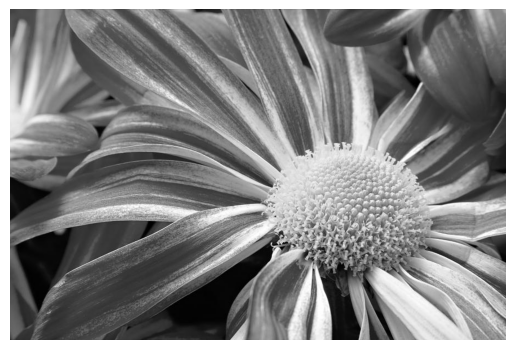

In [ ]:
img_gray_fh = flip_horizontal(img_gray)
print(img_gray_fh.shape[:2])
plt.imshow(img_gray_fh)
plt.axis('off')